In [ ]:
import pandas as pd
import numpy as np
from google.cloud import bigquery

client = bigquery.Client()

query = """
SELECT
  author_id,
  field_id,
  publication_year,
  avg_cd,
  avg_ai
FROM `aiwriting-488923.new.ai_author_field_year_panel_multi`
WHERE window_type = '18m'
"""

df = client.query(query).to_dataframe()

df["author_field"] = df["author_id"].astype(str) + "_" + df["field_id"].astype(str)

In [ ]:
for year in [2021, 2022, 2023, 2024]:
    df[f"ai_{year}"] = df["avg_ai"] * (df["publication_year"] == year)

In [ ]:
# Grand means
grand = df.mean(numeric_only=True)

# Author×Field means
af_means = df.groupby("author_field").mean(numeric_only=True)
df = df.merge(
    af_means,
    left_on="author_field",
    right_index=True,
    suffixes=("", "_af")
)

# Year means
year_means = df.groupby("publication_year").mean(numeric_only=True)
df = df.merge(
    year_means,
    left_on="publication_year",
    right_index=True,
    suffixes=("", "_year")
)

# Residualize CD
df["cd_resid"] = (
    df["avg_cd"]
    - df["avg_cd_af"]
    - df["avg_cd_year"]
    + grand["avg_cd"]
)

# Residualize AI×year terms
for year in [2021, 2022, 2023, 2024]:
    df[f"ai_{year}_resid"] = (
        df[f"ai_{year}"]
        - df[f"ai_{year}_af"]
        - df[f"ai_{year}_year"]
        + grand[f"ai_{year}"]
    )

In [ ]:
import numpy as np

# Select residual columns explicitly
X = df[[f"ai_{year}_resid" for year in [2021, 2022, 2023, 2024]]].copy()
y = df["cd_resid"].copy()

# Convert to float64 explicitly
X = X.astype("float64").values
y = y.astype("float64").values.reshape(-1,1)

# Now safe to invert
XtX_inv = np.linalg.inv(X.T @ X)
beta = XtX_inv @ (X.T @ y)

betas = beta.flatten()

for year, b in zip([2021,2022,2023,2024], betas):
    print(f"beta_{year}: {b}")

beta_2021: -0.1653070735205632
beta_2022: -0.00248511992266566
beta_2023: 0.2743134622424751
beta_2024: 0.33482182047359776


In [ ]:
import statsmodels.api as sm

X = df[[f"ai_{year}_resid" for year in [2021,2022,2023,2024]]].astype("float64")
y = df["cd_resid"].astype("float64")

model_18m = sm.OLS(y, X)
results_18m = model_18m.fit(
    cov_type="cluster",
    cov_kwds={"groups": df["author_field"]}
)

print(results_18m.summary())

                                 OLS Regression Results                                
Dep. Variable:               cd_resid   R-squared (uncentered):                   0.004
Model:                            OLS   Adj. R-squared (uncentered):              0.004
Method:                 Least Squares   F-statistic:                              3518.
Date:                Wed, 18 Mar 2026   Prob (F-statistic):                        0.00
Time:                        20:15:43   Log-Likelihood:                     -1.8680e+06
No. Observations:             5634835   AIC:                                  3.736e+06
Df Residuals:                 5634831   BIC:                                  3.736e+06
Df Model:                           4                                                  
Covariance Type:              cluster                                                  
                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

In [ ]:
import pandas as pd
import numpy as np
from google.cloud import bigquery

client = bigquery.Client()

query = """
SELECT
  author_id,
  field_id,
  publication_year,
  avg_cd,
  avg_ai
FROM `aiwriting-488923.new.ai_author_field_year_panel_multi`
WHERE window_type = '12m'
"""

df = client.query(query).to_dataframe()

df["author_field"] = df["author_id"].astype(str) + "_" + df["field_id"].astype(str)

In [ ]:
for year in [2021, 2022, 2023, 2024]:
    df[f"ai_{year}"] = df["avg_ai"] * (df["publication_year"] == year)

In [ ]:
# Grand means
grand = df.mean(numeric_only=True)

# Author×Field means
af_means = df.groupby("author_field").mean(numeric_only=True)
df = df.merge(
    af_means,
    left_on="author_field",
    right_index=True,
    suffixes=("", "_af")
)

# Year means
year_means = df.groupby("publication_year").mean(numeric_only=True)
df = df.merge(
    year_means,
    left_on="publication_year",
    right_index=True,
    suffixes=("", "_year")
)

# Residualize CD
df["cd_resid"] = (
    df["avg_cd"]
    - df["avg_cd_af"]
    - df["avg_cd_year"]
    + grand["avg_cd"]
)

# Residualize AI×year terms
for year in [2021, 2022, 2023, 2024]:
    df[f"ai_{year}_resid"] = (
        df[f"ai_{year}"]
        - df[f"ai_{year}_af"]
        - df[f"ai_{year}_year"]
        + grand[f"ai_{year}"]
    )

In [ ]:
import numpy as np

# Select residual columns explicitly
X = df[[f"ai_{year}_resid" for year in [2021, 2022, 2023, 2024]]].copy()
y = df["cd_resid"].copy()

# Convert to float64 explicitly
X = X.astype("float64").values
y = y.astype("float64").values.reshape(-1,1)

# Now safe to invert
XtX_inv = np.linalg.inv(X.T @ X)
beta = XtX_inv @ (X.T @ y)

betas = beta.flatten()

for year, b in zip([2021,2022,2023,2024], betas):
    print(f"beta_{year}: {b}")

beta_2021: -0.22722101622136537
beta_2022: -0.048867474976110215
beta_2023: 0.24294329863803912
beta_2024: 0.39769435411618614


In [ ]:
import statsmodels.api as sm

X = df[[f"ai_{year}_resid" for year in [2021,2022,2023,2024]]].astype("float64")
y = df["cd_resid"].astype("float64")

model_12m = sm.OLS(y, X)
results_12m = model_12m.fit(
    cov_type="cluster",
    cov_kwds={"groups": df["author_field"]}
)

print(results_12m.summary())

                                 OLS Regression Results                                
Dep. Variable:               cd_resid   R-squared (uncentered):                   0.006
Model:                            OLS   Adj. R-squared (uncentered):              0.006
Method:                 Least Squares   F-statistic:                              4957.
Date:                Wed, 18 Mar 2026   Prob (F-statistic):                        0.00
Time:                        20:22:58   Log-Likelihood:                     -2.3901e+06
No. Observations:             5437536   AIC:                                  4.780e+06
Df Residuals:                 5437532   BIC:                                  4.780e+06
Df Model:                           4                                                  
Covariance Type:              cluster                                                  
                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

In [ ]:
import pandas as pd
import numpy as np
from google.cloud import bigquery

client = bigquery.Client()

query = """
SELECT
  author_id,
  field_id,
  publication_year,
  avg_cd,
  avg_ai
FROM `aiwriting-488923.new.ai_author_field_year_panel_multi`
WHERE window_type = '24m'
"""

df = client.query(query).to_dataframe()

df["author_field"] = df["author_id"].astype(str) + "_" + df["field_id"].astype(str)

In [ ]:
for year in [2021, 2022, 2023, 2024]:
    df[f"ai_{year}"] = df["avg_ai"] * (df["publication_year"] == year)

In [ ]:
# Grand means
grand = df.mean(numeric_only=True)

# Author×Field means
af_means = df.groupby("author_field").mean(numeric_only=True)
df = df.merge(
    af_means,
    left_on="author_field",
    right_index=True,
    suffixes=("", "_af")
)

# Year means
year_means = df.groupby("publication_year").mean(numeric_only=True)
df = df.merge(
    year_means,
    left_on="publication_year",
    right_index=True,
    suffixes=("", "_year")
)

# Residualize CD
df["cd_resid"] = (
    df["avg_cd"]
    - df["avg_cd_af"]
    - df["avg_cd_year"]
    + grand["avg_cd"]
)

# Residualize AI×year terms
for year in [2021, 2022, 2023, 2024]:
    df[f"ai_{year}_resid"] = (
        df[f"ai_{year}"]
        - df[f"ai_{year}_af"]
        - df[f"ai_{year}_year"]
        + grand[f"ai_{year}"]
    )

In [ ]:
import numpy as np

# Select residual columns explicitly
X = df[[f"ai_{year}_resid" for year in [2021, 2022, 2023, 2024]]].copy()
y = df["cd_resid"].copy()

# Convert to float64 explicitly
X = X.astype("float64").values
y = y.astype("float64").values.reshape(-1,1)

# Now safe to invert
XtX_inv = np.linalg.inv(X.T @ X)
beta = XtX_inv @ (X.T @ y)

betas = beta.flatten()

for year, b in zip([2021,2022,2023,2024], betas):
    print(f"beta_{year}: {b}")

beta_2021: -0.09458406304539409
beta_2022: 0.07372371260408171
beta_2023: 0.3396214761635884
beta_2024: 0.32908011240563023


In [ ]:
import statsmodels.api as sm

X = df[[f"ai_{year}_resid" for year in [2021,2022,2023,2024]]].astype("float64")
y = df["cd_resid"].astype("float64")

model_24m = sm.OLS(y, X)
results_24m = model_24m.fit(
    cov_type="cluster",
    cov_kwds={"groups": df["author_field"]}
)

print(results_24m.summary())

                                 OLS Regression Results                                
Dep. Variable:               cd_resid   R-squared (uncentered):                   0.004
Model:                            OLS   Adj. R-squared (uncentered):              0.004
Method:                 Least Squares   F-statistic:                              2354.
Date:                Wed, 18 Mar 2026   Prob (F-statistic):                        0.00
Time:                        20:24:45   Log-Likelihood:                     -1.0303e+06
No. Observations:             5124693   AIC:                                  2.061e+06
Df Residuals:                 5124689   BIC:                                  2.061e+06
Df Model:                           4                                                  
Covariance Type:              cluster                                                  
                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

In [ ]:
import pandas as pd

data = {
    "year": [2021, 2022, 2023, 2024],

    "coef_12m": [-0.2272, -0.0489, 0.2429, 0.3977],
    "se_12m":   [0.011,   0.010,   0.007,   0.004],

    "coef_18m": [-0.1653, -0.0025, 0.2743, 0.3348],
    "se_18m":   [0.009,   0.009,   0.006,   0.004],

    "coef_24m": [-0.0946, 0.0737,  0.3396, 0.3291],
    "se_24m":   [0.009,   0.008,   0.006,   0.005],
}

df_plot = pd.DataFrame(data)

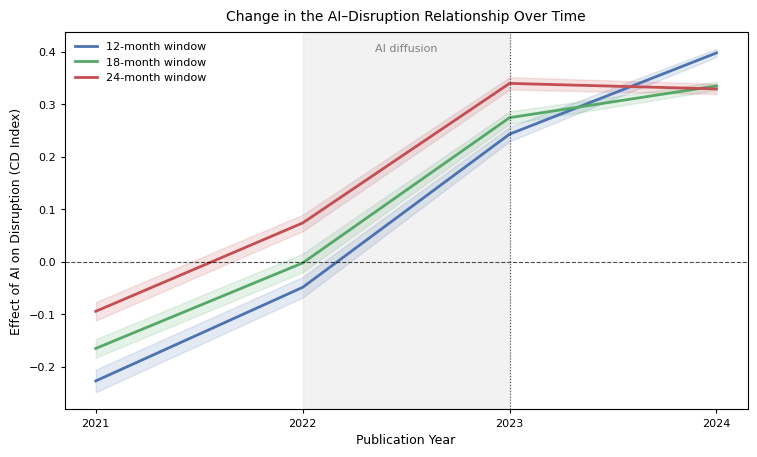

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- GLOBAL STYLE (IMPORTANT) ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
})

fig, ax = plt.subplots(figsize=(7.5, 4.5))  # wider, journal style

# Colors (slightly muted, journal-friendly)
colors = {
    "12m": "#4C72B0",
    "18m": "#55A868",
    "24m": "#C44E52"
}

def plot_line(years, coef, se, label, color):
    coef = np.array(coef)
    se = np.array(se)

    ax.plot(years, coef, label=label, color=color, linewidth=2)

    ax.fill_between(
        years,
        coef - 1.96 * se,
        coef + 1.96 * se,
        color=color,
        alpha=0.15
    )

# Plot lines
plot_line(df_plot["year"], df_plot["coef_12m"], df_plot["se_12m"], "12-month window", colors["12m"])
plot_line(df_plot["year"], df_plot["coef_18m"], df_plot["se_18m"], "18-month window", colors["18m"])
plot_line(df_plot["year"], df_plot["coef_24m"], df_plot["se_24m"], "24-month window", colors["24m"])

# =========================
# SHADED TRANSITION PERIOD
# =========================
ax.axvspan(
    2022, 2023,
    color="gray",
    alpha=0.1
)

# Reference lines (subtle)
ax.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
ax.axvline(2023, color="black", linestyle=":", linewidth=0.8, alpha=0.7)

# Optional annotation (clean and subtle)
ax.text(
    2022.5,
    ax.get_ylim()[1] * 0.95,
    "AI diffusion",
    ha='center',
    va='top',
    fontsize=8,
    color='gray'
)

# Labels
ax.set_xlabel("Publication Year")
ax.set_ylabel("Effect of AI on Disruption (CD Index)")

# Title
ax.set_title("Change in the AI–Disruption Relationship Over Time", pad=8)

# Ticks
ax.set_xticks([2021, 2022, 2023, 2024])

# Box (thin, clean)
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color("black")

# Legend
ax.legend(frameon=False, loc="upper left")

# Layout
plt.tight_layout(pad=0.5)

# Save BEFORE showing
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

fig.savefig(
    "figure1_ai_disruption.pdf",
    format="pdf",
    bbox_inches="tight"
)

fig.savefig(
    "figure1_ai_disruption.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from google.cloud import bigquery
import pandas as pd
import statsmodels.formula.api as smf

client = bigquery.Client()

# load data
query = """
SELECT *
FROM `aiwriting-488923.new.ai_author_panel_accel_yearfe`
"""

df = client.query(query).to_dataframe()

# ensure type
df['year_str'] = df['publication_year'].astype(str)

results = {}

for w in ['12m', '18m', '24m']:

    df_w = df[df['window_type'] == w].copy()

    model = smf.ols(
        "delta_cd ~ delta_ai + C(year_str)",
        data=df_w
    ).fit(cov_type='HC1')

    results[w] = model

    print(f"\n=== Acceleration with Year FE ({w}) ===")
    print(model.summary())


=== Acceleration with Year FE (12m) ===
                            OLS Regression Results                            
Dep. Variable:               delta_cd   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1011.
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:08:35   Log-Likelihood:            -2.6031e+06
No. Observations:             2054148   AIC:                         5.206e+06
Df Residuals:                 2054144   BIC:                         5.206e+06
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------